Welcome to Leah and Tanner's Data Wrangling Final Project. We have chosen data about resturaunts in North America. The “1500 North American Restaurants Dataset” contains information on a wide range of dining establishments in the United States and Canada. The dataset contains features for each restaurant, such as name, city, state, country, type of cuisine, pickup and/or delivery options, and customer rating. This project plans to explore restaurant characteristics and customer ratings in order to better understand the customer experience within the restaurant industry. For example, how factors such as location, cuisine type, and service options relate to restaurant ratings and popularity. By understanding these relationships, restaurants can potentially improve customer satisfaction and their operational efficiency.

We begin by loading in the data in the cell below. Data is being accessed initially via Kaggle as a CSV: https://www.kaggle.com/datasets/saketk511/1500-north-american-resturants

Data is included in this repository and loaded locally as a CSV file.

https://github.com/leahrcordova/Data-Wrangling-Final-Project-Leah-Tanner-.git

In [ ]:
# Import dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("North America Restaurants.csv")

print(df.head())

Saving North America Restaurants (1).csv to North America Restaurants (1).csv
                             name         city state  zipcode country  \
0                     Burger King    Manitowoc    WI    54220      US   
1                    Petro-Canada      Airdrie    AB      T4A      CA   
2                        Boba Bae  Ashwaubenon    WI    54304      US   
3            1001 Nights Shawarma    Kitchener    ON      N2C      CA   
4  Chirpyhut Fried Chicken (JlgJ)     Richmond    BC  V6X 2B8      CA   

                                            cuisines  pickup_enabled  \
0  American, Burger, Burgers, Family Meals, Fast ...            True   
1  Ben & Jerry's, Café/Thé, Coffee/Tea, Convenien...            True   
2  American, Asian Food, Bubble Tea, Coffee & Tea...            True   
3  Beau, Bon, Local, Chicken, Dessert, Desserts, ...            True   
4  Ailes, Allergy Friendly, American, Beau, Bon, ...            True   

   delivery_enabled  weighted_rating_value  aggreg

In order to use this data to answer our reseach questions, we must first clean it up. When looking at the head of the data, it appears that the "cuisines" column is not standardized at the moment.

In [ ]:
# Getting rid of convenience and grocery stores
df = df[~df['name'].str.lower().str.contains('petro|shell|esso|chevron|7-eleven|circle k|gas|convenience', na=False)]

# Rename "weighted rating" to more accurate "average rating"
df = df.rename(columns={'weighted_rating_value': 'average_rating'})

# Fill missing values with ""
df['cuisines'] = df['cuisines'].fillna("")

# Reset index and assign an create an ID for each restaurant
df = df.reset_index(drop=True)
df['restaurant_id'] = df.index

# Split cuisines by commas and strip spaces and uppercases
df['cuisine_list'] = df['cuisines'].str.split(',')
df['cuisine_list'] = df['cuisine_list'].apply(lambda x: [c.strip().lower() for c in x if c.strip() != ""])

# Expand cuisine labels individually
df_exploded = df.explode('cuisine_list')

# Categorize by testing if a string is contained in a label
categories = [
    df_exploded['cuisine_list'].str.contains('dessert|ice cream|frozen|ben & jerry\'s|cake|candy|sweet|crèmerie|crème glacée|gâteries rafraîchissantes|cool treats', na=False),
    df_exploded['cuisine_list'].str.contains('vegetarian|vegan|vé', na=False),
    df_exploded['cuisine_list'].str.contains('caf|coffee|pastry|bakery|hot drinks|hot teas', na=False),
    df_exploded['cuisine_list'].str.contains('sandwich|sub', na=False),
    df_exploded['cuisine_list'].str.contains('seafood|shrimp|fish|sushi', na=False),
    df_exploded['cuisine_list'].str.contains('breakfast|pancake|waffle|brunch',na=False),
    df_exploded['cuisine_list'].str.contains('pizza',na=False),
    df_exploded['cuisine_list'].str.contains('chicken|poulet',na=False),
    df_exploded['cuisine_list'].str.contains('fast food',na=False),
    df_exploded['cuisine_list'].str.contains('burger',na=False),
    df_exploded['cuisine_list'].str.contains('wing',na=False),
    df_exploded['cuisine_list'].str.contains('bbq|barbecue|barbeque|southern|soul food', na=False),
    df_exploded['cuisine_list'].str.contains('chin',na=False),
    df_exploded['cuisine_list'].str.contains('alcohol|beer|wine|bar food|bar and grill|alcool|bière|pub food|bud light|budweiser|liquor|spirits|corona|stella artois',na=False),
    df_exploded['cuisine_list'].str.contains('ital|pasta',na=False),
    df_exploded['cuisine_list'].str.contains('mexica|tacos|taco|burritos',na=False),
    df_exploded['cuisine_list'].str.contains('indian|indien	',na=False),
    df_exploded['cuisine_list'].str.contains('mediterranean|méditerranéen',na=False),
]

# Assign choices
choices = [
    'desserts',
    'vegetarian/vegan',
    'cafes',
    'sandwiches',
    'seafood',
    'breakfast',
    'pizza',
    'chicken',
    'fast food',
    'burgers',
    'wings',
    'bbq/southern',
    'chinese',
    'bars',
    'italian',
    'mexican',
    'indian',
    'mediterranean'
]

# Select desired categories and default others
df_exploded['cuisine_group'] = np.select(categories, choices, default = "other")

# Set priority for choosing main cuisine label
priority_order = [
    'pizza',
    'mexican',
    'italian',
    'chinese',
    'indian',
    'mediterranean',
    'seafood',
    'wings',
    'burgers',
    'bbq/southern',
    'sandwiches',
    'cafes',
    'breakfast',
    'vegetarian/vegan',
    'bars',
    'desserts',
    'other'
]

# Un-explode data into 1 cuisine label per restaurant and create final data frame
df_exploded['cuisine_group'] = pd.Categorical(df_exploded['cuisine_group'], categories=priority_order, ordered=True)
df_final = df_exploded.groupby('restaurant_id', as_index=False).agg({
    'name': 'first',
    'cuisine_group': 'min',
    'average_rating': 'first',
    'city': 'first',
    'state': 'first',
    'zipcode': 'first',
    'country': 'first',
    'pickup_enabled': 'first',
    'delivery_enabled': 'first',
})
df_final.head()

,restaurant_id,name,cuisine_group,average_rating,city,state,zipcode,country,pickup_enabled,delivery_enabled
0,0,Burger King,burgers,2.4,Manitowoc,WI,54220,US,True,True
1,1,Boba Bae,cafes,4.0,Ashwaubenon,WI,54304,US,True,True
2,2,1001 Nights Shawarma,mediterranean,4.6,Kitchener,ON,N2C,CA,True,True
3,3,Chirpyhut Fried Chicken (JlgJ),wings,4.6,Richmond,BC,V6X 2B8,CA,True,True
4,4,7 West Cafe,pizza,4.4,Toronto,ON,M4Y 1R4,CA,True,True


[Leah & Tanner] Now that we have loaded in the data and organized our cuisines column, we will begin with some exploratory plots and statistics to visualize and explore general distributions before analyzing relationships relevant to our research questions.

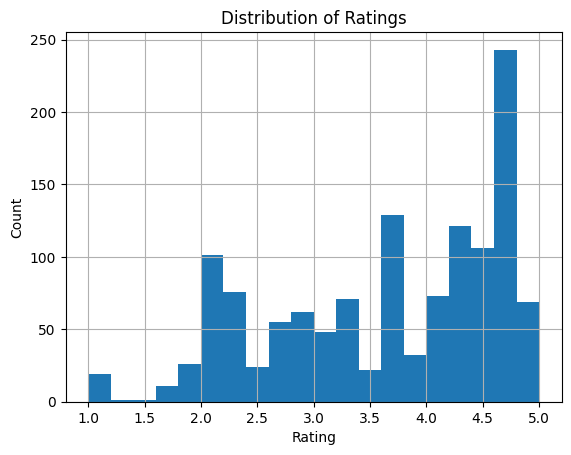

In [ ]:
df_final["average_rating"].hist(bins = 20)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

Above is the distribution of the ratings amoung resturaunts. There is a good spread of ratings from 1-5 stars. It is somewhat uniform with some skew right. This is good to know when looking at what customers have to say in the grand scheme of food judgement.

Now let's take a look at the summary statistics of the ratings:

In [ ]:
df_final['average_rating'].describe().round(2)

,average_rating
count,1290.00
mean,3.62
std,1.02
min,1.00
25%,2.80
50%,3.80
75%,4.50
max,5.00


While it is useful to see an overall summary of the numbers, lets explore the utility of a visual of the types of cuisines that that the establishments in the dataset serve. Burgers were hot on the menu as they lead the way making up about 200 of the resturaunts in our dataset.

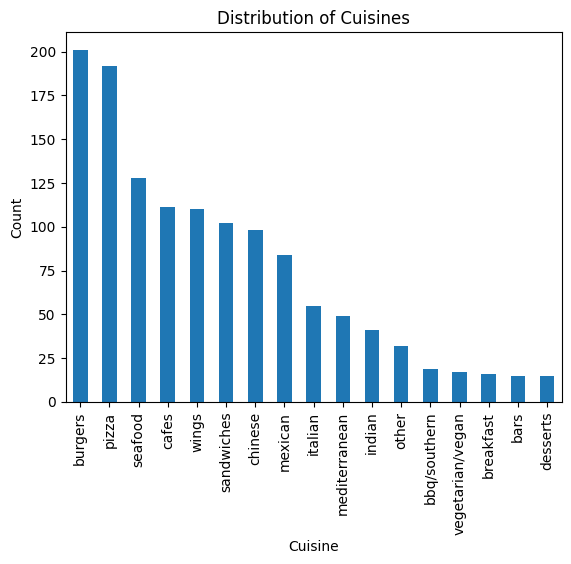

In [ ]:
df_final['cuisine_group'].value_counts().plot(kind = 'bar')
plt.title('Distribution of Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Count')
plt.show()

In [ ]:
df_final['pickup_enabled'].value_counts(normalize = True)

,proportion
pickup_enabled,
True,0.739535
False,0.260465


About 74 persent of the resturaunts indicated that pickup is an option to carry out food.

In [ ]:
df_final['delivery_enabled'].value_counts(normalize = True)

,proportion
delivery_enabled,
True,1.0


This cell indicates that delivery is an option at every resturaunt in the dataset, which we were skeptical of at first, but with Doordash and other delivery services, it seems that all food spots can take advantage of goods to go!

The following cell indicates that 77.4% of the resturaunts included in the data set are not fast food joints. The rest are!

In [ ]:
df_final['is_fast_food'].value_counts(normalize = True)

,proportion
is_fast_food,
False,0.773643
True,0.226357


If you look at the chart below, you will see a bar chart of the top 10 cities with the most number of resturaunts in the data.

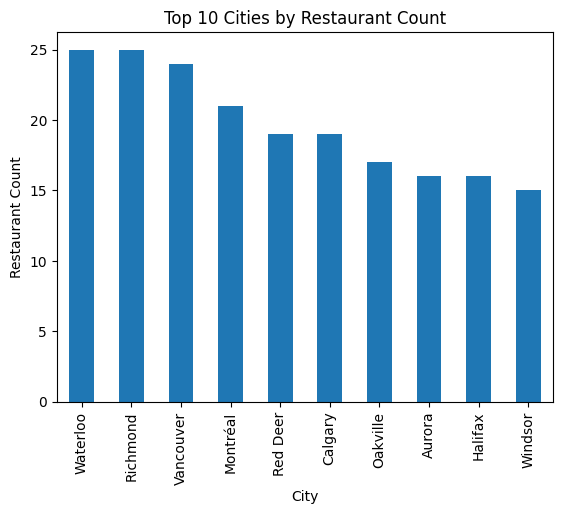

In [ ]:
df_final['city'].value_counts().head(10).plot(kind = 'bar')
plt.title('Top 10 Cities by Restaurant Count')
plt.xlabel('City')
plt.ylabel('Restaurant Count')
plt.show()

Zooming out from city to states and provinces we have provided a bar chart of the top 10 states/provinces by resturaunt count below.

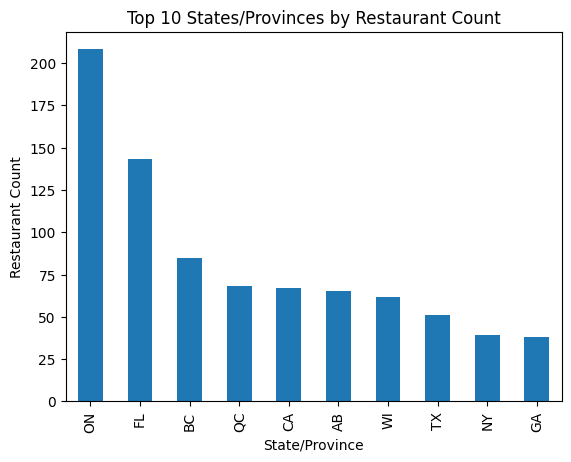

In [ ]:
df_final['state'].value_counts().head(10).plot(kind = 'bar')
plt.title('Top 10 States/Provinces by Restaurant Count')
plt.xlabel('State/Province')
plt.ylabel('Restaurant Count')
plt.show()

[Leah] Question 1: What differences in average restaurant ratings exist across cuisine types? In order to adress this question, let's first examine the average rating for each cuisine group.

In [ ]:
cuisine_rating = df_final.groupby('cuisine_group')['average_rating'].mean().round(2)
cuisine_rating.sort_values(ascending = False)

/tmp/ipykernel_7875/1989500440.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cuisine_rating = df_final.groupby('cuisine_group')['average_rating'].mean().round(2)


,average_rating
cuisine_group,
bars,4.44
mediterranean,4.23
cafes,4.17
chinese,3.97
italian,3.83
seafood,3.75
vegetarian/vegan,3.72
pizza,3.58
burgers,3.53


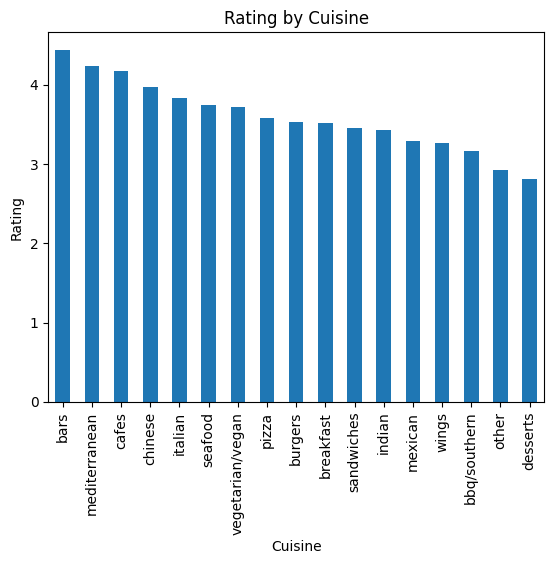

In [ ]:
cuisine_rating.sort_values(ascending = False).plot(kind = 'bar')
plt.title('Rating by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Rating')
plt.show()

In [ ]:
df_final['average_rating'].mean().round(2)

np.float64(3.62)

Now that we've seen the distributions across cuisines, we will calculate the average rating overall, which comes out to be 3.62.

Which cuisine has the most ratings submitted? We can examine that using counts for each below.

In [ ]:
cuisine_count = df_final.groupby('cuisine_group')['average_rating'].count()
cuisine_count.sort_values(ascending = False)

/tmp/ipykernel_7875/3134592506.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cuisine_count = df_final.groupby('cuisine_group')['average_rating'].count()


,average_rating
cuisine_group,
burgers,201
pizza,192
seafood,128
cafes,111
wings,110
sandwiches,102
chinese,98
mexican,84
italian,55


While bars show the highest average rating (4.44) and desserts the lowest(2.81), both categories have very small sample sizes (n = 15), making them less reliable. In order to see averages of cuisines with more reliable samples, we will filter by n = 30.

In [ ]:
popular_cuisines = cuisine_count[cuisine_count >= 30].index
cuisine_filtered = cuisine_rating[cuisine_rating.index.isin(popular_cuisines)]
cuisine_filtered.sort_values(ascending = False)

,average_rating
cuisine_group,
mediterranean,4.23
cafes,4.17
chinese,3.97
italian,3.83
seafood,3.75
pizza,3.58
burgers,3.53
sandwiches,3.46
indian,3.43


When filtering for restaurants that have recieved at least 30 ratings, the highest rated cuisine changes to mediterranean	at 4.23 and the lowest rated cuisine changes to wings at 3.27. We can also note that the average rating for the most rated restaurant cuisines (burgers - 3.53/pizza - 3.58/seafood - 3.75) all lie relatively around the overall average of 3.62, which makes sense with most of the data coming from these cuisines. Let's split the data at the overall average rating and compare.

In [ ]:
overall_average = df_final['average_rating'].mean()

above_average = cuisine_filtered[cuisine_filtered >= overall_average]
print(above_average)

below_average = cuisine_filtered[cuisine_filtered < overall_average]
print(below_average)

cuisine_group
italian          3.83
chinese          3.97
mediterranean    4.23
seafood          3.75
cafes            4.17
Name: average_rating, dtype: float64
cuisine_group
pizza         3.58
mexican       3.29
indian        3.43
wings         3.27
burgers       3.53
sandwiches    3.46
other         2.93
Name: average_rating, dtype: float64


Within cuisines with greater than 30 ratings, Italian, Chinese, Mediterranean, Seafood, and Cafes score higher than average, and Pizza, Mexican, Indian, Wings, Burgers, and Sandwiches score below average. Now let's examine spread within each cuisine.

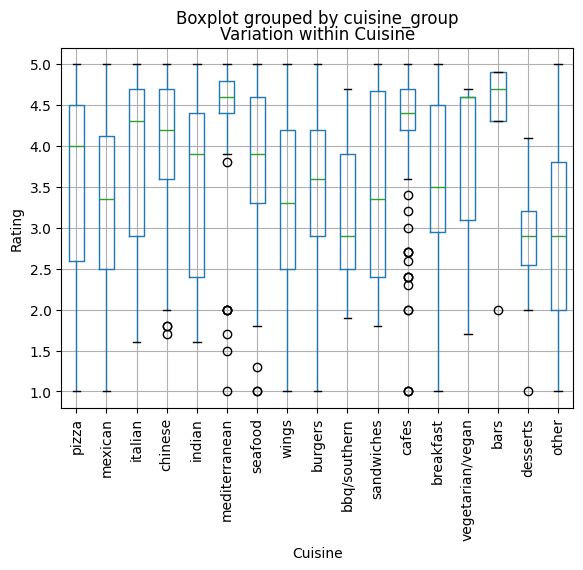

In [ ]:
df_final.boxplot(column = 'average_rating', by = 'cuisine_group', rot = 90)
plt.title('Variation within Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Rating')
plt.show()

The boxplot shows that cuisine type is associated with differences in both average ratings and variability. Several of the higher rated cuisines show clustering near the upper end of the ratings scale, however they also display occassional lower outliers, suggesting while these high rated cuisines mostly perform well, a small number of ratings fall well below the main cluster of values. In contrast, many of the other cuisines have wider spreads, indicating more variability.

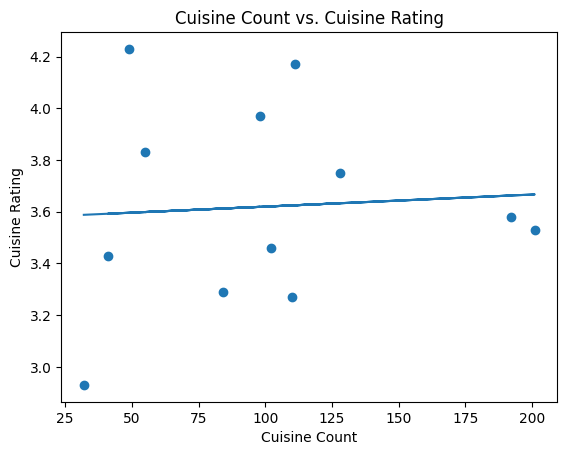

In [ ]:
cuisine_count_filtered = cuisine_count[cuisine_count.index.isin(cuisine_filtered.index)]
plt.scatter(cuisine_count_filtered, cuisine_filtered)
m, b = np.polyfit(cuisine_count_filtered, cuisine_filtered, 1)
plt.plot(cuisine_count_filtered, m*cuisine_count_filtered + b)
plt.title('Cuisine Count vs. Cuisine Rating')
plt.xlabel('Cuisine Count')
plt.ylabel('Cuisine Rating')
plt.show()

After plotting a scatter plot with a correlation line, it can be seen that there is a slightly positive correlation between more ratings and a higher average rating, however this positive trend is very slight, and does not indicate a strong relatioship directly between rating count per cuisine and higher average rating.

[Tanner] It is important to explore the impact that the geographical location or region has on the ratings of the food. We can explore this impact by answering the Second Question of: Which geographical areas (cities, states, or zip codes) contain the most restaurants and what is each area’s average rating?

Let's begin with making a simpler dataframe with only the geographical compontents of the resturaunts, along with the ratings they recieved.

In [ ]:
geo_data = df[["name", "city", "state", "zipcode", "country", "average_rating"]]

geo_data = geo_data.dropna(subset=["city", "average_rating"])

geo_data.head(10)

,name,city,state,zipcode,country,average_rating
0,Burger King,Manitowoc,WI,54220,US,2.4
1,Boba Bae,Ashwaubenon,WI,54304,US,4.0
2,1001 Nights Shawarma,Kitchener,ON,N2C,CA,4.6
3,Chirpyhut Fried Chicken (JlgJ),Richmond,BC,V6X 2B8,CA,4.6
4,7 West Cafe,Toronto,ON,M4Y 1R4,CA,4.4
5,El Valle Verde,Cincinnati,OH,45205,US,2.4
6,Rock Salad,Dubuque,IA,52001,US,4.3
7,Etoile Mirabel,Mirabel,QC,J7J,CA,4.6
8,J. Alexander's : Jacksonville,Jacksonville,FL,32246,US,4.1
9,A&W,Red Deer,AB,T4R,CA,3.7


Getting a count of resturaunts by each city will be crucial in comparing averages so that we can get an accurate total count when calculating mean ratings in each city.

In [ ]:
city_counts = geo_data["city"].value_counts()

city_counts.head(10)

,count
city,
Waterloo,25
Richmond,25
Vancouver,24
Montréal,21
Red Deer,19
Calgary,19
Oakville,17
Aurora,16
Halifax,16


Waterloo and Richmond lead the dataset, with the most resturaunts in their respective cities. We will now filter out cities with less than 10 ratings and calculate amoung those who are left in order to see the city with the highest average rating amoung their resturaunts.

In [ ]:
valid_cities = city_counts[city_counts >= 10].index

geo_df_filtered = geo_data[geo_data["city"].isin(valid_cities)]

average_city_rating = geo_data.groupby("city")["average_rating"].mean()
average_city_rating.sort_values(ascending = False).head(10)

,average_rating
city,
Jamaica,5.00
Sarasota,5.00
Silver Spring,5.00
St. Louis Park,5.00
Saint Johns,5.00
Bella Vista,5.00
Clearwater,5.00
Mcallen,5.00
Knoxville,4.95


Wow! We see a handful of towns were actually able to pull off having only 5 star ratings at their reviewed establisments! 8 of them to be exact.

In [ ]:
city_summary = geo_df_filtered.groupby("city").agg(
    restaurant_count=("name", "count"),
    avg_rating=("average_rating", "mean")
)

city_summary = city_summary.sort_values(by="restaurant_count", ascending=False)

city_summary.head(10)

,restaurant_count,avg_rating
city,,
Waterloo,25,4.432000
Richmond,25,4.276000
Vancouver,24,4.270833
Montréal,21,4.700000
Calgary,19,4.463158
Red Deer,19,4.010526
Oakville,17,4.423529
Aurora,16,4.525000
Halifax,16,4.693750


Now that we have the answer to our question in the tables and analysis above, let us have some fun with our matplotlib skills and pivot tables!

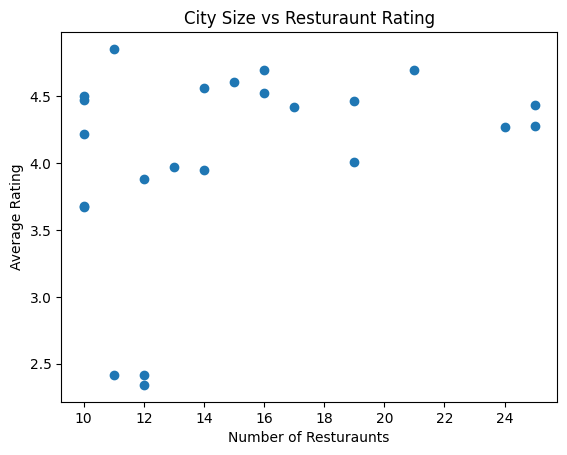

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(city_summary["restaurant_count"], city_summary["avg_rating"])
plt.xlabel("Number of Resturaunts")
plt.ylabel("Average Rating")
plt.title("City Size vs Resturaunt Rating")

plt.show()


This is very good that during this analysis there is not a clear trend seen in the graph between the size of the city and the average rating of that city. This could have led to a faulty analysis and conclusion to this question, but it seems that there is not a clear trend between the two components.

In order to further explore this idea, in the cell below we will create a new score collumn in the smaller dataframe that will multiply the average rating in the city, by the log transformed column of the number of resturaunts the city had, in order to see a more fair comparison if the resturaunt had less resturaunts in town.

In [ ]:
import numpy as np

city_summary["score"] = (
    city_summary["avg_rating"] * np.log(city_summary["restaurant_count"])
)

city_summary.sort_values(by="score", ascending=False).head(10)

,restaurant_count,avg_rating,score
city,,,
Montréal,21,4.700000,14.309255
Waterloo,25,4.432000,14.266058
Richmond,25,4.276000,13.763913
Vancouver,24,4.270833,13.572938
Calgary,19,4.463158,13.141496
Halifax,16,4.693750,13.013838
Aurora,16,4.525000,12.545964
Oakville,17,4.423529,12.532803
Windsor,15,4.606667,12.475085


In [ ]:

ratings = city_summary["avg_rating"].values

print("Mean:", np.mean(ratings))
print("Median:", np.median(ratings))
print("Std Dev:", np.std(ratings))

Mean: 4.058233654139193
Median: 4.276
Std Dev: 0.7169562040172354


To cap off this question we will finish with somem multi level analysis in the form of hierarchichal indexing and put our city and state information in a digestable dataframe.

In [ ]:
city_and_state = geo_df_filtered.groupby(["state", "city"]).agg(resturaunt_count= ("name", "count"), avg_rating= ("average_rating", "mean"))
city_and_state.head(10)

resturaunt_count  avg_rating
state city                                   
AB    Airdrie                  10    4.500000
      Calgary                  19    4.463158
      Edmonton                 13    3.969231
      Red Deer                 19    4.010526
BC    Richmond                 21    4.542857
      Surrey                   10    4.470000
      Vancouver                24    4.270833
CO    Aurora                    1    3.200000
FL    Miami                    10    2.280000
IA    Waterloo                  2    2.400000

Lastly this pivot table will allow us to compare states with ease:

In [ ]:
pivot = geo_df_filtered.pivot_table(values = "average_rating", index = "state", aggfunc = ["mean", "count"])
pivot

,mean,count
,average_rating,average_rating
state,,
AB,4.222951,61
BC,4.410909,55
CO,3.200000,1
FL,2.280000,10
IA,2.400000,2
IL,3.400000,1
NC,3.300000,1
NS,4.693750,16


[Leah] Question 3: What are the most common restaurant cuisines in North America and are certain cuisines more concentrated in particular areas? We have already answered part of this question simply with our counts data, however, let's examine it with alongside geographical data as well.

In [ ]:
top_five_count = df_final['cuisine_group'].value_counts().head(5)
print(top_five_count)

bottom_five_count = df_final['cuisine_group'].value_counts().sort_values(ascending = True).head(5)
print(bottom_five_count)

cuisine_group
burgers    201
pizza      192
seafood    128
cafes      111
wings      110
Name: count, dtype: int64
cuisine_group
bars                15
desserts            15
breakfast           16
vegetarian/vegan    17
bbq/southern        19
Name: count, dtype: int64


Assuming more restaurants means a more popular cuisine type, the top 5 are Burgers, Pizza, Seafood, Cafes, and Wings, and the bottom 5 are Bars, Desserts, Breakfast, Vegetarian/Vegan, and BBQ/Southern.

What about the relationship between location and average rating/number of resturants per cuisine per area? Let's start by splitting up regions explicitly. We'll start with country.

In [ ]:
df_us = df_final[df_final['country'] == "US"]
print(df_us['cuisine_group'].value_counts().head(5))
print(df_us['average_rating'].mean().round(2))

df_ca = df_final[df_final['country'] == "CA"]
print(df_ca['cuisine_group'].value_counts().head(5))
print(df_ca['average_rating'].mean().round(2))

cuisine_group
burgers       136
pizza         116
wings          87
sandwiches     86
mexican        80
Name: count, dtype: int64
3.21
cuisine_group
pizza      76
burgers    65
chinese    63
seafood    62
cafes      45
Name: count, dtype: int64
4.36


The top 5 cuisine types (in terms of number of resturaunts in each cuisine) in the United States are Burgers, Pizza, Wings, Sandwiches, and Mexican. While in Canada, the top 5 cuisines are Pizza, Burgers, Chinese, Seafood, and Cafes. These are a mixture of the top 5 overall, which makes sense! There is also more data for American restaurants than Canadian restuarants. There is a very large difference in average ratings per country, with Canada averaging about 1.1 points higher than the US! (3.21 vs 4.36!). Now let's move onto states/provinces.

In [ ]:
state_counts = df_final['state'].value_counts()

top_five_states = state_counts.head(5)
df_top_states = df_final[df_final['state'].isin(top_five_states.index)]
state_cuisine_top = df_top_states.groupby(['state', 'cuisine_group']).agg(count=('cuisine_group', 'size'), avg_rating=('average_rating', 'mean')).round(2)
idx = state_cuisine_top.groupby(level=0)['count'].idxmax()
top_cuisine_state = state_cuisine_top.loc[idx].reset_index()
print(top_cuisine_state)

  state cuisine_group  count  avg_rating
0    BC       chinese     23        4.36
1    CA         pizza     11        3.22
2    FL         pizza     29        2.92
3    ON       seafood     38        4.35
4    QC         pizza     22        4.42


/tmp/ipykernel_8455/1618088373.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_cuisine_top = df_top_states.groupby(['state', 'cuisine_group']).agg(count=('cuisine_group', 'size'), avg_rating=('average_rating', 'mean')).round(2)


The top 5 states/provinces, in terms of number restaurants, are Ontario, Florida, British Columbia, Quebec, California, which leans Canada-heavy in terms of top number of restuarants. The top cuisine in each of these state/provinces, respectively, was Chinese, Pizza, Pizza, Seafood, and Pizza. As seen before, we can notice that the average rating for these cuisines is much higher in Canada than the US. Canada's ratings are 4.36(British Columbia), 4.35(Ontario), and 4.42(Quebec) while the US has 3.22(California) and 2.92(Florida).

This observed difference between Canadian and US ratings could reflect underlying differences beyond cuisine. For example, this could be attributed to differences in food quality, cultural norms, or platform usage between countries. Further real world analysis would be needed to determine whether or not this gap represents a true difference.

In [ ]:
bottom_five_states = state_counts.tail(5)
df_bottom_states = df_final[df_final['state'].isin(bottom_five_states.index)]
state_cuisine_bottom = df_bottom_states.groupby(['state', 'cuisine_group']).agg(count=('cuisine_group', 'size'), avg_rating=('average_rating', 'mean')).round(2)
idx2 = state_cuisine_bottom.groupby(level=0)['count'].idxmax()
bottom_cuisine_state = state_cuisine_bottom.loc[idx2].reset_index()
print(bottom_cuisine_state)

  state cuisine_group  count  avg_rating
0    AK       burgers      1         3.2
1    CT       burgers      1         3.5
2    DE       burgers      1         3.3
3    ID       burgers      1         3.3
4    SD         cafes      1         4.3


/tmp/ipykernel_8455/3758526768.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_cuisine_bottom = df_bottom_states.groupby(['state', 'cuisine_group']).agg(count=('cuisine_group', 'size'), avg_rating=('average_rating', 'mean')).round(2)


The bottom five states contain very few restaurants, with each cuisine appearing only once, indicating that there is insufficient data to draw meaningful conclusions about cuisine popularity or ratings in these regions.

[Tanner] Question 4: Do restaurants that offer pickup and/or delivery services tend to receive a higher rating than those who do not, on average?

We will leave delivery out of this because we discovered that all resturaunts in this dataset deliver in some way.

Lets get an idea of the columns we are working with:

In [ ]:
extras = df[["name","pickup_enabled", "average_rating"]]
extras.head(5)

,name,pickup_enabled,average_rating
0,Burger King,True,2.4
1,Boba Bae,True,4.0
2,1001 Nights Shawarma,True,4.6
3,Chirpyhut Fried Chicken (JlgJ),True,4.6
4,7 West Cafe,True,4.4


In [ ]:
summary = extras.groupby("pickup_enabled")["average_rating"].mean()

This question and visual became pretty simple once delivery was taken out of the equation due to earlier exploration. You can see that there is a 0.3 higher mean rating of resturaunts with pickup which shows it makes a differenct to consumers. Lets picture this.

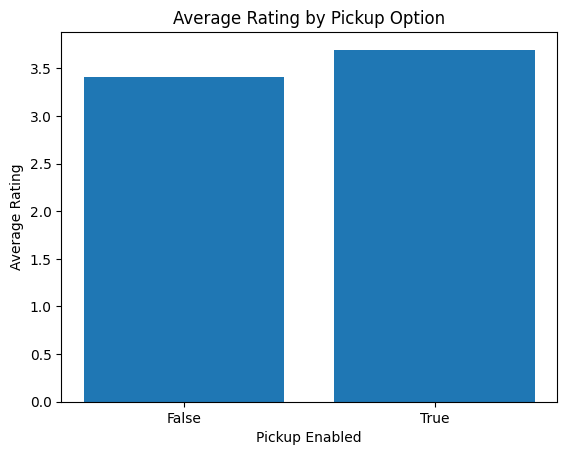

In [ ]:
import matplotlib.pyplot as plt

plt.bar(summary.index.astype(str), summary.values)

plt.xlabel("Pickup Enabled")
plt.ylabel("Average Rating")
plt.title("Average Rating by Pickup Option")

plt.show()

Conclusion:

Our analysis of the data explored how restaurant characteristics, particularly cuisine type, geographic location, and pickup ability, relate to average ratings across North America.

It was seen, overall, that cuisine type is associated with differences in both average ratings and variability, but these differences are not always large. One thing that did emerge was, geographically, Canadian locations general exhibit higher average ratings than locations within the US. Along with these findings it is also important to note that there were a couple of cities that only had five star ratings from guests who reviewed resturaunts within that city. Some of these cities recieved substantially less ratings than other cities with high ratings as well, so we created a weighted system that factored in the number of reviews left. After this was implimented we saw that Montréal had the best average review. So we would reccomend relying on a good bite to eat if you're ever near by.

However, findings in this analysis should be interpreted with caution as many regions and cuisines has small sample sizes which limits the relaibility of conclusion based on these samples. Additionally, restaurant ratings can be subjective and reflect differences in users rather than true differences in food/restaurant quality.

Thank you for walking through our skills and this dataset with us! We have shown some key skills in cleaning the Northern Amicican resturaunt data set and answering some key questions that could be be beneficial to restaurant owners and business analyst.